## 1. LIBRARIES:

In [1]:
"""LIBRARIES"""
import os
import numpy as np
import matplotlib.pyplot as plt
import wavepal as wv
import spot_wave as sw

sw.setup_carmcmc()


CARMCMC has been successfully loaded with all its C++ libraries!


<module 'carmcmc' from '/home/uri/spot_wave_v1/WAVEPAL/carmcmc_pack/carma_pack/src/carmcmc/__init__.py'>

### 1.1. DATASET:

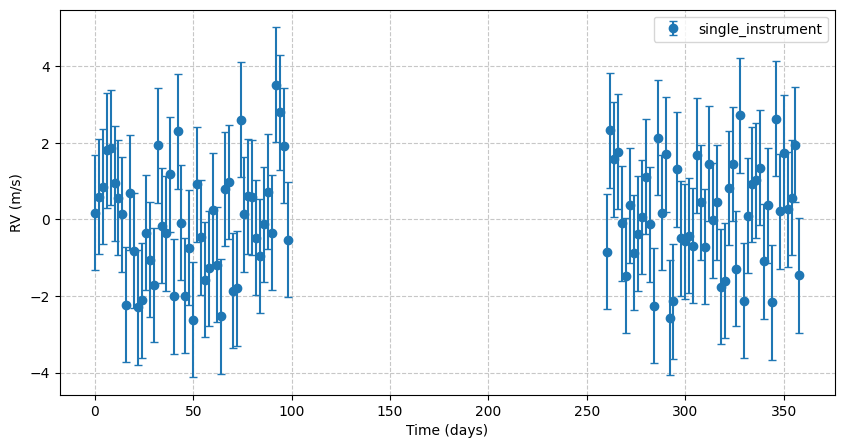

<module 'matplotlib.pyplot' from '/home/uri/spot_wave_v1/lib/python3.10/site-packages/matplotlib/pyplot.py'>

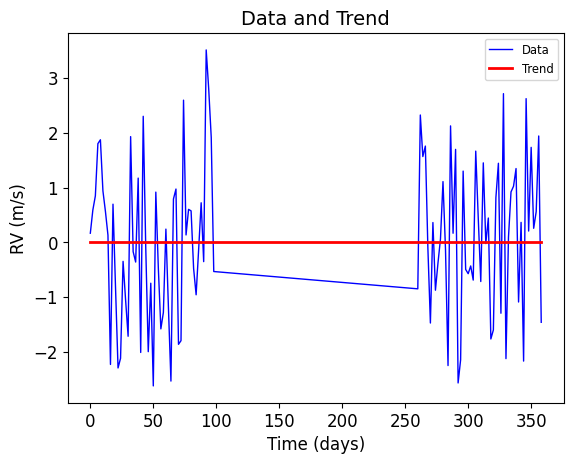

In [2]:
# Repository:
main_directory = "/home/uri/juliet/Targets/starsim/PAPER/NEW_CONFIGS/ONE_ACTIVE_LONGITUDE_SPOT_LIFETIME/Prot_055.0d_medio/N0100/"
filename = main_directory + "rvs_lifetime_01.0Prot_055.000d.dat"

# Load RV data and plot:
myt, myRV, myRV_err, instruments = sw.load_rv_file(filename,subtract_instrument_means=True)
sw.rv_plot(myt, myRV, rv_err=myRV_err, instruments=instruments)

# WAVEPAL object creation and data check:
wavelet = wv.Wavepal(myt, myRV, "Time", "RV", t_units="days", mydata_units="m/s")
wavelet.check_data()

# WAVEPAL plotting:
plot_trend = wavelet.plot_trend(pol_degree=-1)
plot_trend

### 1.2. IS THE DATASET SUITABLE FOR A WAVELET ANALYSIS?

In [3]:
# Test CWT feasibility:
is_good = sw.test_cwt_feasibility(wavelet, w0=8.5)

Preliminary CWT Feasibility Analysis

Total points (N): 100
Recommended w0 range: [5.5, 32.70]
Selected w0 (8.5) is within the optimal range.

Avg cadence: 3.62 days
Baseline (Tb): 358.00 days

Theoretical Limits
Disclaimer: These are just mathematical guidelines, not hard walls.

P_min (theoretical): ~8.88 days
P_max (theoretical): ~37.11 days

Green light: Dataset looks solid to search for periods in that range.


### 1.3. CARMCMC:

In [4]:
# CARMCMC is used in WAVEPAL to model the correlated noise in the data and 
# to estimate the confidence levels!
wavelet.choose_trend_degree(-1)  # Trend polynomial degree used in the analysis (0=cte, 1=linear, 2=quadratic,..., -1=no trend)
wavelet.trend_vectors()  # Trend vectors are calculated and stored in the object. Needed for CARMCMC.

# CARMCMC folder:
path_to_figure_folder = main_directory + "figures_carma/"
os.makedirs(path_to_figure_folder, exist_ok=True)

# CARMCMC parameters and figure generation:
wavelet.carma_params(make_carma_fig=True, nbins=20, dpi=400, path_to_figure_folder=path_to_figure_folder)


****************************
*        CARMA PACK        *
****************************

FIRST ROUND (to estimate the number of independent samples): with  10000  samples
**********************************************************************************************************
Running sampler...
Number of steps added: 1
Number of tracked steps added: 1
Setting starting values...
 Drawn from priors
 ...Initializing    1.3998
   0.8582
   0.0304
  -4.5587

Burning in... (5000 iterations)

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
**************************************************Average RAM Acceptance Rate is 0.1898
*

Sampling...

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************
Calculating sigma...
Calculating log-likelihoods...
Decorrelation length (in number of samples) - Estimation:  43

SECOND ROUND: generates 

## 2. SCALOGRAM:

Weights for the scalogram and Shannon-Nyquist exclusion zone:


  0%|                                                                                                                                 | 0/100 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 105.07it/s]


Re-estimated period range: from  4.027826228049076  to  53.445680289042485
Main loop, over the time-frequency plane:


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 374/374 [00:06<00:00, 59.78it/s]


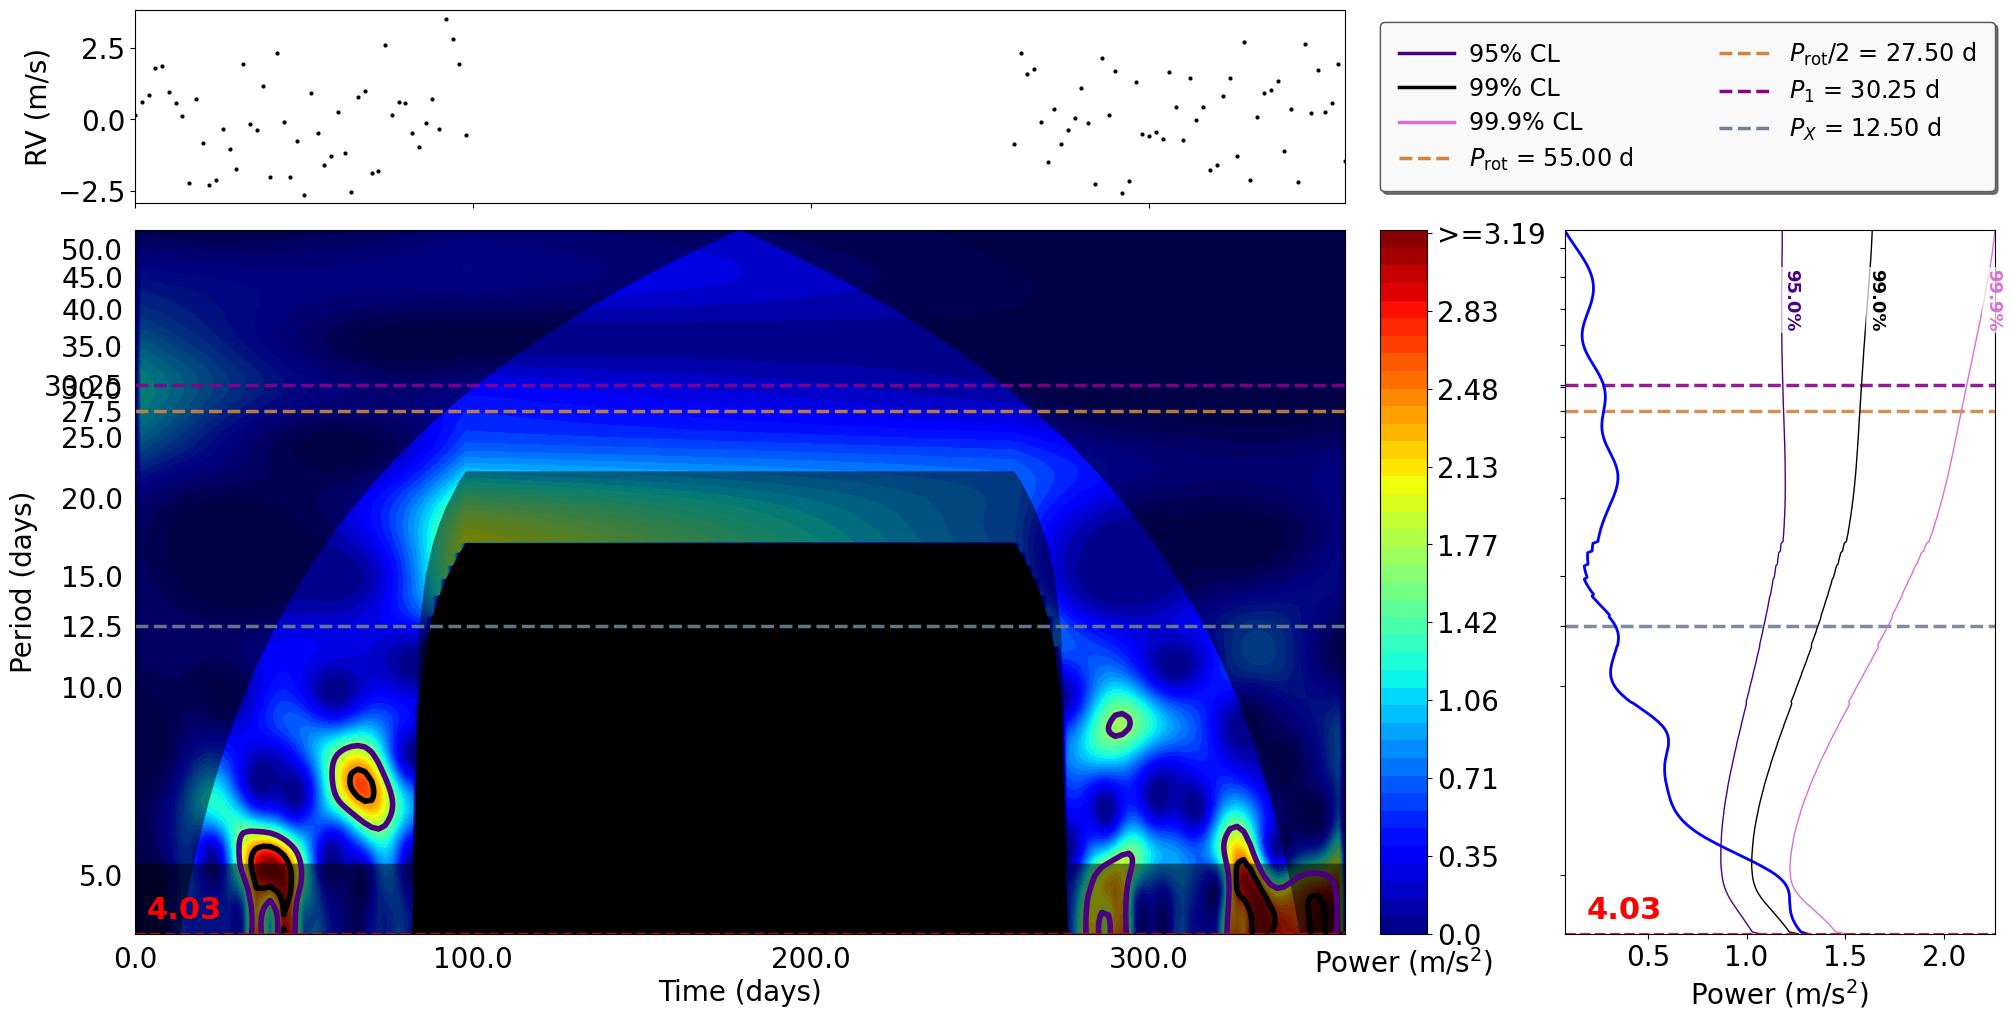

In [5]:
# WAVEPAL scalogram parameters:
percentile = (95., 99., 99.9) # Confidence levels to be calculated in the scalogram (percentile of the CARMCMC distribution)
min_period_analysis = 1.    # Minimum period analyzed in the scalogram
max_period_analysis = 200.  # Maximum period analyzed in the scalogram

# Periods and times to mark for the scalogram:
# Periods:
p_rot = 55.0
p_rot_half = p_rot / 2.0
p_planets = [30.25]              # o [30.25, 8.6] si hay más de uno
p_unknown = [12.5]               # picos sin identificar
# Times:
time_string=[0., 100., 200., 300., 400., 500., 600., 700., 800., 900., 1000.]
period_string=[1.,2.,3.,4.,5., 10., 15., 20., 25., 30., 35., 40., 45., 50.,
                         55., 60., 65., 70., 75., 80., 85., 90., 95., 100.] 
period_string=period_string + p_planets + p_unknown + [p_rot, p_rot_half]
dashed_periods=[]

fig = sw.scalogram.analyze_and_plot(
    wavelet,
    w0=7.,
    deltaj=0.01,
    permin=min_period_analysis,
    permax=max_period_analysis,
    percentile=percentile,
    time_string=time_string,                 
    period_string=period_string,             
    dashed_periods=dashed_periods,           
    activity_periods=[p_rot, p_rot_half],  
    planet_periods=p_planets,               
    other_periods=p_unknown,                
)

### 2.1. LOOP $\omega_{0}$

In [6]:
# Basic w0 loop: one scalogram PDF per w0, no period-range parsing
output_dir = os.path.join(main_directory, "SCALOGRAM_LOOP")

sw.scalogram.w0_loop(
    wavelet, output_dir,
    w0_min=5.5, w0_max=9.5, w0_step=2.0,
    permin=min_period_analysis, permax=max_period_analysis, deltaj=0.05,
    percentile=percentile, 
    save_period_ranges=False, time_string=time_string,                 
    period_string=period_string, dashed_periods=dashed_periods,           
    activity_periods=[p_rot, p_rot_half], planet_periods=p_planets,               
    other_periods=p_unknown,
)


Weights for the scalogram and Shannon-Nyquist exclusion zone:


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 417.67it/s]


Re-estimated period range: from  4.1410638364252055  to  66.25702138280329
Main loop, over the time-frequency plane:


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 81/81 [00:01<00:00, 55.29it/s]


Weights for the scalogram and Shannon-Nyquist exclusion zone:


...

Weights for the scalogram and Shannon-Nyquist exclusion zone:


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 549.76it/s]


Re-estimated period range: from  4.1410638364252055  to  39.396660623658555
Main loop, over the time-frequency plane:


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 66/66 [00:01<00:00, 54.11it/s]


[]

In [7]:
# Same loop, but also capturing wavepal's "Re-estimated period range" text
# for each w0 
output_dir = os.path.join(main_directory, "SCALOGRAM_LOOP")

sw.scalogram.w0_loop(
    wavelet, output_dir,
    w0_min=5.5, w0_max=9.5, w0_step=2.0,
    permin=min_period_analysis, permax=max_period_analysis, deltaj=0.05,
    percentile=percentile, 
    save_period_ranges=True, time_string=time_string,                 
    period_string=period_string, dashed_periods=dashed_periods,           
    activity_periods=[p_rot, p_rot_half], planet_periods=p_planets,               
    other_periods=p_unknown,
)
# period_ranges -> list[(w0, period_min, period_max)], also saved to
# output_dir/period_ranges.txt


Period ranges saved to: /home/uri/juliet/Targets/starsim/PAPER/NEW_CONFIGS/ONE_ACTIVE_LONGITUDE_SPOT_LIFETIME/Prot_055.0d_medio/N0100/SCALOGRAM_LOOP/period_ranges.txt


[(5.5, 4.1410638364252055, 66.25702138280329),
 (7.5, 4.1410638364252055, 48.50297863126287),
 (9.5, 4.1410638364252055, 39.396660623658555)]

## 3. FILTER:

### 3.1. Simple filter (single w0 range, band around Prot)

In [8]:
w0_grid = sw.make_w0_grid(5.5, 6.5, 1.0)

## Single-filter sweep:
best_single = sw.single_filter_sweep(
    myt, myRV, myRV_err, w0_grid,
    bands=[(p_rot - 0.5, p_rot + 0.5), (p_rot_half - 0.5, p_rot_half + 0.5)],
    p_rot=p_rot, p_rot_half=p_rot_half, p_planets=p_planets,
)

# Save the best single-filter result to a file:
print(f"Best w0={best_single['w0']:.3f}  S_score={best_single['S_score']:.4g}")
sw.save_winner_file(
    myt, best_single["residuals"], myRV_err,
    os.path.join(main_directory, "single_filter_winner.dat"),
)


Weights for the scalogram and Shannon-Nyquist exclusion zone:


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 88.53it/s]


Re-estimated period range: from  4.027826228049076  to  68.1197597967067
Main loop, over the time-frequency plane:


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 409/409 [00:07<00:00, 56.87it/s]


[single_filter_sweep] w0=5.500 -> S_score=2.929
Weights for the scalogram and Shannon-Nyquist exclusion zone:


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 89.50it/s]


Re-estimated period range: from  4.027826228049076  to  57.28166182099476
Main loop, over the time-frequency plane:


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 384/384 [00:04<00:00, 81.97it/s]


[single_filter_sweep] w0=6.500 -> S_score=1.508
[single_filter_sweep] BEST w0=6.500 -> S_score=1.508
Best w0=6.500  S_score=1.508


'/home/uri/juliet/Targets/starsim/PAPER/NEW_CONFIGS/ONE_ACTIVE_LONGITUDE_SPOT_LIFETIME/Prot_055.0d_medio/N0100/single_filter_winner.dat'

### 3.2. Double filter (bands around Prot and Prot/2, order 1 and/or 2)

In [9]:
# Order 1: Filter Prot band first, then Prot/2 band
order1 = dict(
    w0_grid_1=sw.make_w0_grid(5.5, 6.5, 1.0),     # filters the Prot band first
    w0_grid_2=sw.make_w0_grid(5.5, 11.5, 1.0),  # then the Prot/2 band
    hw_1=0.5, hw_2=0.5, # half-widths of the two filters
)

# Order 2: Filter Prot/2 band first, then Prot band
# order2 = dict(
#     w0_grid_1=sw.make_w0_grid(11.5, 14.5, 0.1),   # filters the Prot/2 band first
#     w0_grid_2=sw.make_w0_grid(5.5, 7.0, 0.1),     # then the Prot band
#     hw_1=0.5, hw_2=0.5, # half-widths of the two filters
# )

# For the double-filter sweep, we can use only one order, or both orders:
best_double = sw.run_double_filter_sweep(
    myt, myRV, myRV_err,
    prot_value=p_rot, prot_half_value=p_rot_half, planet_periods=p_planets,
    order1=order1, 
    # order2=order2,
)

# Save the best double-filter result to a file:
print(f"Best order={best_double['order']} "
      f"w0_1={best_double['w0_1']:.3f} w0_2={best_double['w0_2']:.3f}  "
      f"S_score={best_double['S_score']:.4g}")

sw.save_winner_file(
    myt, best_double["residuals"], myRV_err,
    os.path.join(main_directory, "double_filter_winner.dat"),
)


Weights for the scalogram and Shannon-Nyquist exclusion zone:


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 95.12it/s]


Re-estimated period range: from  4.027826228049076  to  68.1197597967067
Main loop, over the time-frequency plane:


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 409/409 [00:05<00:00, 70.16it/s]


Weights for the scalogram and Shannon-Nyquist exclusion zone:


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 104.57it/s]


Re-estimated period range: from  4.027826228049076  to  32.44673579998428
Main loop, over the time-frequency plane:


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 302/302 [00:04<00:00, 65.10it/s]


[double_filter_sweep] order=1 w0_1=5.500 w0_2=5.500 -> S_score=4.42
[double_filter_sweep] order=1 w0_1=5.500 w0_2=6.500 -> S_score=1.858
[double_filter_sweep] order=1 w0_1=5.500 w0_2=7.500 -> S_score=1.07
[double_filter_sweep] order=1 w0_1=5.500 w0_2=8.500 -> S_score=0.7181
[double_filter_sweep] order=1 w0_1=5.500 w0_2=9.500 -> S_score=0.5277
[double_filter_sweep] order=1 w0_1=5.500 w0_2=10.500 -> S_score=0.4125
[double_filter_sweep] order=1 w0_1=5.500 w0_2=11.500 -> S_score=0.3374
[double_filter_sweep] order=1 w0_1=6.500 w0_2=5.500 -> S_score=4.961
[double_filter_sweep] order=1 w0_1=6.500 w0_2=6.500 -> S_score=2.035
[double_filter_sweep] order=1 w0_1=6.500 w0_2=7.500 -> S_score=1.155
[double_filter_sweep] order=1 w0_1=6.500 w0_2=8.500 -> S_score=0.7702
[double_filter_sweep] order=1 w0_1=6.500 w0_2=9.500 -> S_score=0.5653
[double_filter_sweep] order=1 w0_1=6.500 w0_2=10.500 -> S_score=0.4427
[double_filter_sweep] order=1 w0_1=6.500 w0_2=11.500 -> S_score=0.3635
[double_filter_sweep] BE

'/home/uri/juliet/Targets/starsim/PAPER/NEW_CONFIGS/ONE_ACTIVE_LONGITUDE_SPOT_LIFETIME/Prot_055.0d_medio/N0100/double_filter_winner.dat'

### 3.3. CONAN fit on the winning residual

In [ ]:
# Planet parameters for CONAN:
planet_pars, n_planets = sw.build_planet_pars([
    dict(T_0=[(3.2, 0.2)], Period=[(19.25, 0.01)],
        Eccentricity=[0], omega=[90], K=[(0.1, 5.0, 10.0)],
    )
])

# Run CONAN on the filtered data file (filter winner) and extract metrics and posteriors:
sw.run_conan_fit(
    filtered_data_files=["double_filter_winner.dat"],
    data_path=main_directory,
    output_folder=os.path.join(main_directory, "CONAN_OUT_2ble"),
    planet_pars=planet_pars, m_star=(0.467, 0.02),
    gamma_prior=[(0, 30)], n_planets=n_planets,
)

metrics = sw.extract_conan_metrics(os.path.join(main_directory, "CONAN_OUT_2ble"), n_data_points=len(myt))
k_posteriors = sw.extract_all_k_posteriors(os.path.join(main_directory, "CONAN_OUT_2ble"), n_planets=n_planets)
k_med, k_lo1, k_hi1, k_lo3, k_hi3 = sw.extract_k_posterior("conan_out_2ble/")


Linking the last created lightcurve object to the rv object for parameter linking. if this is not the related LC object, input the correct one using `lc_obj` argument of `load_rvs()`
.
Rescaled data columns of double_filter_winner.dat with method:med_sub
# ============ Planet parameters (Transit and RV) setup ========================================================== 
name                       fit 	prior                              	note
[rho_star]/Duration        n   	F(0)                               	#choice in []|unit(gcm^-3/days)
--------repeat this line & params below for multisystem, adding '_planet_number' to the names e.g RpRs_1 for planet 1, ...
RpRs                       n   	F(0)                               	#range[-0.5,0.5]
Impact_para                n   	F(0)                               	#range[0,2]
T_0                        y   	N(3.2,0.2)                         	#unit(days)
Period                     y   	N(19.25,0.01)                      	#range[0,inf]days
[E

100%|▉| 5682/5683 [01:20<00:00, 70.29it/s, +500 | bound: 8 | nc: 1 | ncall: 115537 | eff(%):  5.374 | loglstar: -170.861 | logz: -179.867 +/-  0.127 | dlogz: 



Dynesty chain written to disk as /home/uri/juliet/Targets/starsim/PAPER/NEW_CONFIGS/ONE_ACTIVE_LONGITUDE_SPOT_LIFETIME/Prot_055.0d_medio/N0100/CONAN_OUT_2ble/chains_dict.pkl. Run `result=CONAN.load_result()` to load it.

============ Sampling Finished ==============================================[0.02hrs]

Making corner plot(s) ...
----> saved 1 corner plot(s) as /home/uri/juliet/Targets/starsim/PAPER/NEW_CONFIGS/ONE_ACTIVE_LONGITUDE_SPOT_LIFETIME/Prot_055.0d_medio/N0100/CONAN_OUT_2ble/corner_*.png [0.88 secs]


Creating *out.dat files using the median posterior ...
    - Writing RV output to file: /home/uri/juliet/Targets/starsim/PAPER/NEW_CONFIGS/ONE_ACTIVE_LONGITUDE_SPOT_LIFETIME/Prot_055.0d_medio/N0100/CONAN_OUT_2ble/out_data/double_filter_winner_rvout.dat

 ----> Plotting figures using median posterior values ...[0.34 secs]

 ----> Plotting figures using max posterior values ...[0.34 secs]

Computing AIC, BIC stats ...[0.00 secs]



['lc'] Output files, [], loaded into result ob